1) Charakterizácia ochorenia (niektoré biomarkery):
- M_protein type: Určuje podtyp myelómu. Napr. IgA a Light Chain Only sú spojené s vyšším rizikom poškodenia obličiek. (Otestovať koreláciu s creatinínom)
- Serum M-protein: Meria nádorovú záťaž. (Skúsiť vzťah s počtom myelómov alebo ich objemom)
2) Nádorová záťaž:
- Plasmocyte count FC: Definuje stupeň ochorenia. Pre diagnózu MM je typicky vyžadované > 10 %. (Otestovať vzťah s objemom a štádiom ochorenia)
- Beta2 microglobulin: Kľúčový prognostický faktor. Jeho zvýšená hladina (nad 3,5 mg/l) koreluje s väčšou nádorovou záťažou a horšou prognózou. (Počet/objem a taktiež stupeň ochorenia.
3) Poškodenie orgánov a komplikácie:
- Calcium total level: Hyperkalcémia (zvýšený vápnik) je bežný príznak deštrukcie kostí myelómovými bunkami (Počet/Objem a taktiež stupeň ochorenia)
- Creatinine level: Skúsť taktiež otestovať vzťah medzi počtom a objemom a takisto M_protein type (IgA a LConly)
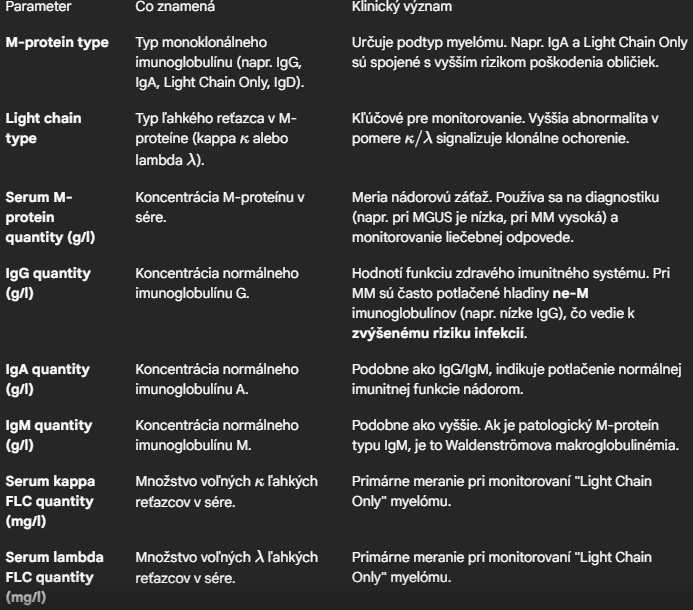
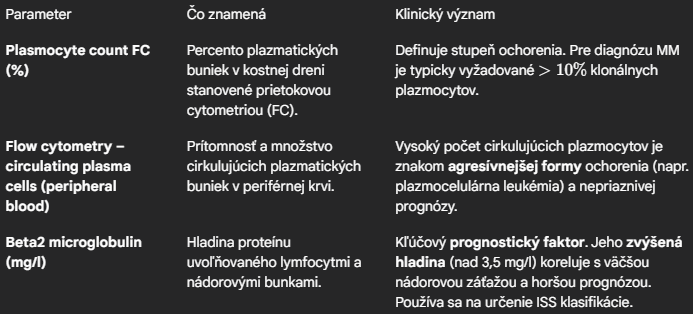

ARTICLE NOTES TO TEST

- &#9989; The diagnosis of myeloma is based on the presence of at least 10% clonal bone marrow plasma cells and monoclonal protein in serum or urine
- &#9989; high levels of serum β2-microglobulin => High risk disease (Stage III)
- &#9989; normal levels of serum β2-microglobulin => Standard risk disease (Stage I)
- &#9989; Myeloma-related organ dysfunction (CRAB criteria) -> Hypercalcemia (serum calcium >11.5 mg/dl [2.88 mmol/liter])
- &#9989; Renal insufficiency (serum creatinine >2 mg/dl [177 μmol/liter])
- &#9989; Stage I: serum β2-microglobulin <3.5 mg/liter, serum albumin ≥3.5 g/dl
- &#9989; Stage II: serum β2-microglobulin, <3.5mg/liter plus serum albumin <3.5 g/dl; or serum β2-microglobulin 3.5 to <5.5 mg/liter regardless of serum albumin level
- &#9989; Stage III: serum β2-microglobulin ≥5.5 mg/liter
- mean serum protein and the beta-2 microglobulin decreased after treatment, whereas the serum albumin increased (p < 0.01)

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, spearmanr, kruskal
from sklearn.preprocessing import StandardScaler

In [22]:
# Load clinical dataset
df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df.head()

,Patient ID,line of treatment,M-protein type,Light chain type,Serum M-protein quantity (g/l),Serum kappa FLC quantity (mg/l,Serum lambda FLC quantity (mg/l),IgG quantity (g/l),IgA quantity (g/l),IgM quantity (g/l),Plasmocyte count FC (%),Flow cytometry – circulating plasma cells (peripheral blood),Calcium total level (mmol/l),Creatinine level (µmol/l),Beta2 microglobulin (mg/l),ISS classification,Treatment regimen,Maximal response to treatment,MM associated amyloidosis,Follow - up
0,Myel_001,1st line,IgG,Kappa,21.4,143.00,9.25,32.87,1.59,0.82,0.86,NaN,2.37,81.0,2.02,Stage 1,bortezomib + lenalidomid + dexamethason,MR,no,NaN
1,Myel_002,1st line,IgA,Kappa,1.0,8870.00,2.10,1.90,0.73,0.05,12.00,NaN,2.44,51.0,4.71,Stage 2,bortezomib + cyklofosfamid + dexamethason,NaN,no,NaN
2,Myel_003,1st line,IgG,Kappa,1.1,287.00,7.46,6.66,0.87,0.28,6.50,yes,2.46,56.0,1.57,Stage 1,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
3,Myel_004,1st line,IgA,Kappa,0.0,1585.17,4.64,6.30,2.23,0.51,NaN,NaN,2.24,169.0,5.89,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
4,Myel_005,1st line,IgA,Lambda,14.8,23.40,1219.00,4.48,30.19,0.14,4.00,yes,2.22,189.0,15.75,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN


In [6]:
nan_counts = df.isna().sum()
print(nan_counts)

Patient ID                                                       0
line of treatment                                                4
M-protein type                                                   0
Light chain type                                                 0
Serum M-protein quantity (g/l)                                  12
Serum kappa FLC quantity (mg/l                                  10
Serum lambda FLC quantity (mg/l)                                10
IgG quantity (g/l)                                               3
IgA quantity (g/l)                                               4
IgM quantity (g/l)                                               4
Plasmocyte count FC (%)                                         19
Flow cytometry – circulating plasma cells (peripheral blood)    19
Calcium total level (mmol/l)                                     2
Creatinine level (µmol/l)                                        2
Beta2 microglobulin (mg/l)                                    

In [19]:
# NUMBER OF NAN FOR EACH PATIENT
nan_per_patient = df.isna().sum(axis=1)
result = pd.DataFrame({'Patient ID': df['Patient ID'], 'NaN_count': nan_per_patient})
result = result.sort_values(by='NaN_count', ascending=False)
print(result.to_string())

   Patient ID  NaN_count
46   Myel_052         14
64   Myel_070         14
24   Myel_026          6
19   Myel_021          6
45   Myel_051          6
18   Myel_020          5
41   Myel_046          5
36   Myel_041          5
44   Myel_050          5
47   Myel_053          5
50   Myel_056          4
68   Myel_078          4
22   Myel_024          4
17   Myel_019          4
8    Myel_009          4
69   Myel_079          4
65   Myel_071          4
70   Myel_080          4
25   Myel_027          3
40   Myel_045          3
51   Myel_057          3
35   Myel_040          3
3    Myel_004          3
1    Myel_002          3
38   Myel_043          3
33   Myel_038          3
29   Myel_031          2
55   Myel_061          2
61   Myel_067          2
0    Myel_001          2
23   Myel_025          2
14   Myel_016          2
32   Myel_036          2
31   Myel_034          2
27   Myel_029          2
20   Myel_022          2
21   Myel_023          2
9    Myel_010          2
13   Myel_015          2


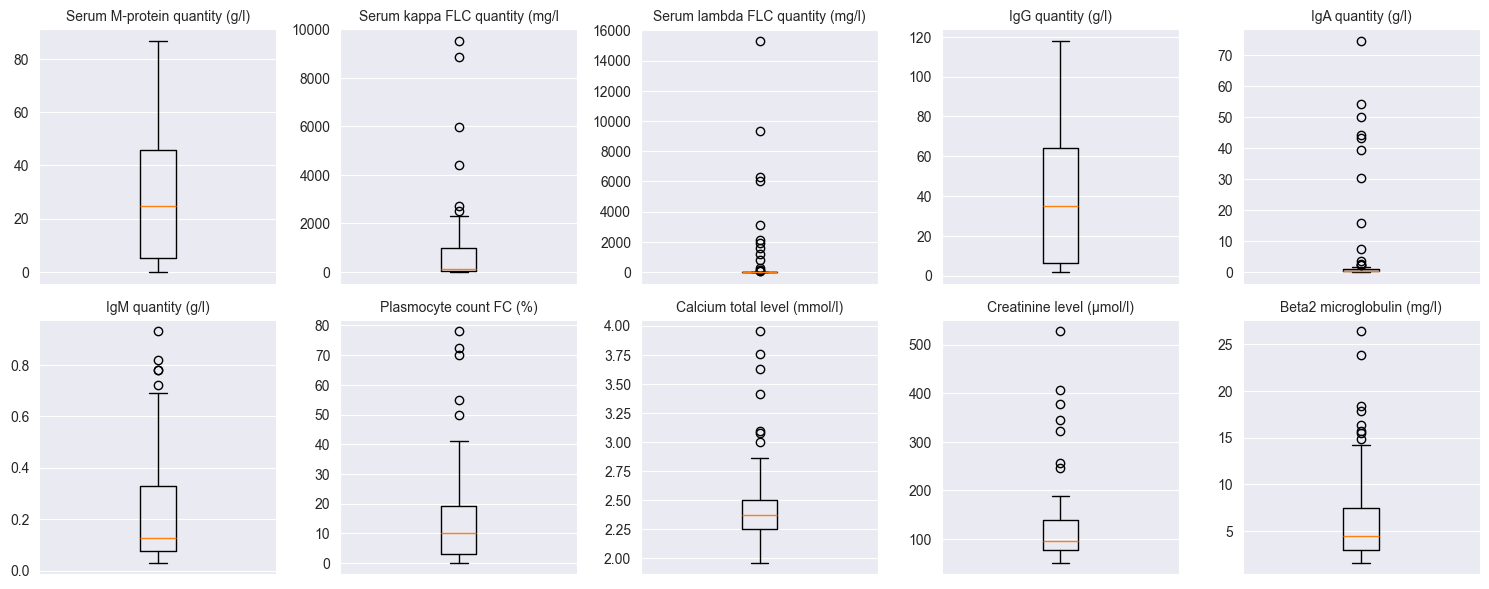

In [7]:
# BOXPLOT VISUALIZATION
numeric_cols = df.select_dtypes(include=['number']).columns

n_cols = len(numeric_cols)
cols_per_row = 5
rows = (n_cols + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col, fontsize=10)
    plt.xticks([])
plt.tight_layout()
plt.show()

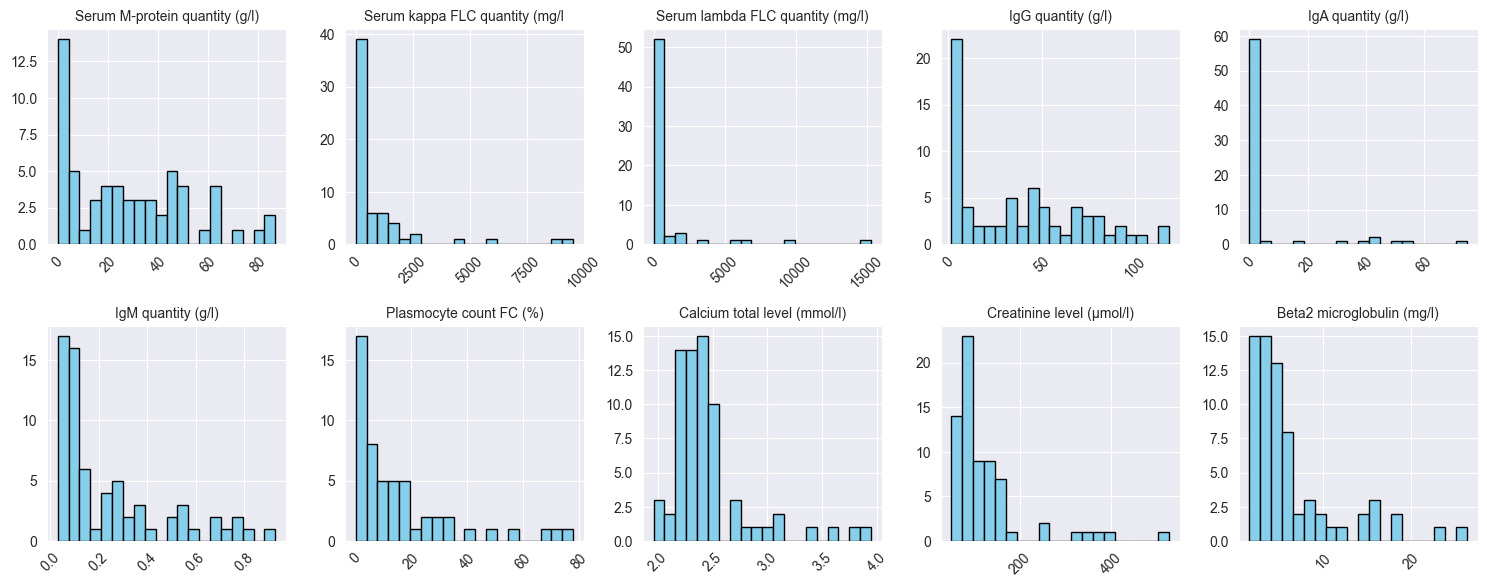

In [26]:
# HISTOGRAM VISUALIZATION
plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=10)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

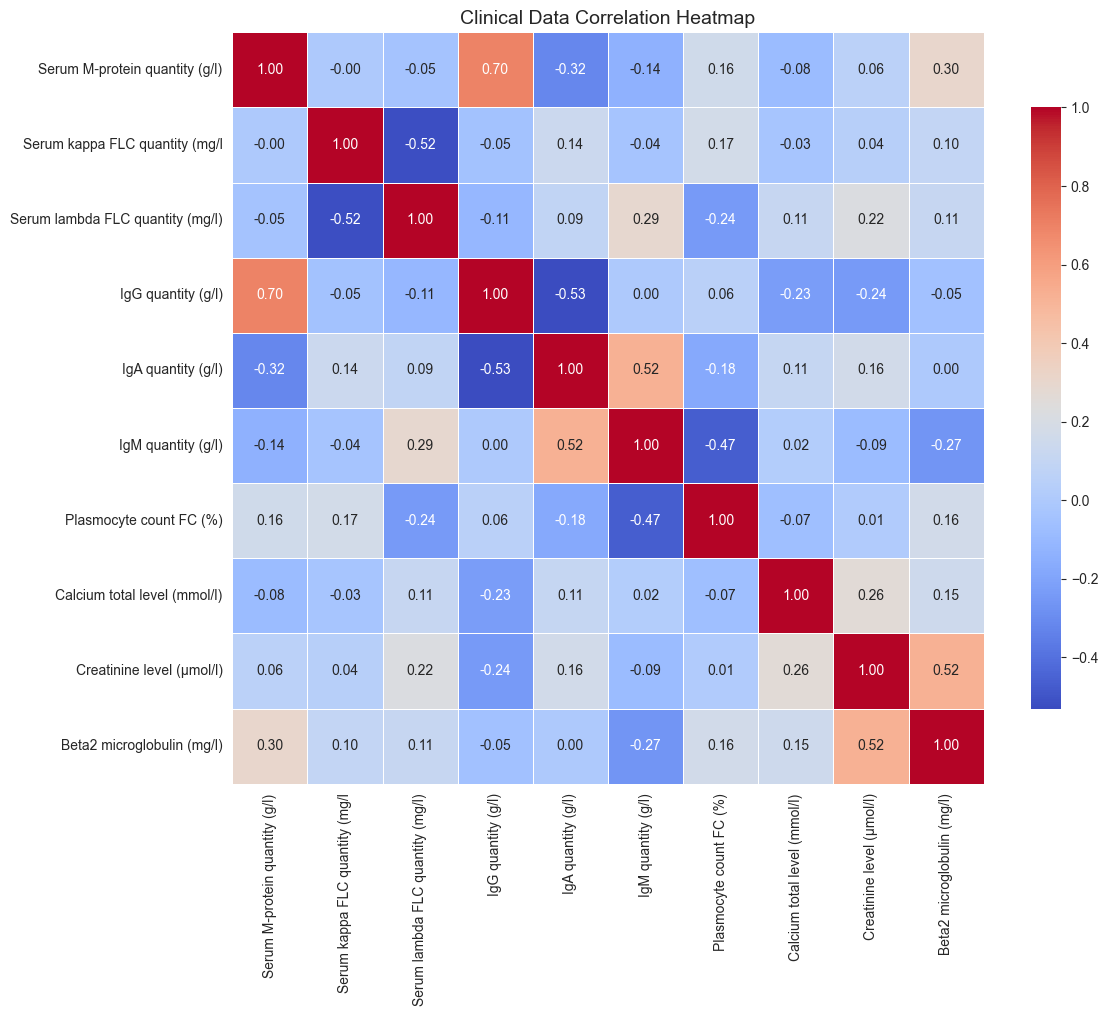

In [27]:
# HEATMAP
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr(method="spearman")  # pearson/spearman
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Clinical Data Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# NORMALITY TEST
for column in numeric_cols:
    data = df[column].dropna()
    if len(data) < 3:
        continue
    _, p = shapiro(data)
    print(f"{column}: {p} -> Normality: {p > 0.05}")

Serum M-protein quantity (g/l): 0.00079869496824886 -> Normality: False
Serum kappa FLC quantity (mg/l: 8.797125616012289e-13 -> Normality: False
Serum lambda FLC quantity (mg/l): 5.578054498564823e-15 -> Normality: False
IgG quantity (g/l): 3.3747953240441965e-05 -> Normality: False
IgA quantity (g/l): 6.7925865431204356e-15 -> Normality: False
IgM quantity (g/l): 2.9993118404976564e-08 -> Normality: False
Plasmocyte count FC (%): 7.600677260764896e-08 -> Normality: False
Calcium total level (mmol/l): 1.5001521184219956e-09 -> Normality: False
Creatinine level (µmol/l): 5.765492227746324e-11 -> Normality: False
Beta2 microglobulin (mg/l): 1.4214849185837948e-09 -> Normality: False


In [29]:
# NORMALITY TEST WITH REPLACED NANs
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

for column in numeric_cols:
    data = df[column].dropna()
    if len(data) < 3:
        continue
    _, p = shapiro(data)
    print(f"{column}: {p} -> Normality: {p > 0.05}")

Serum M-protein quantity (g/l): 0.0006557869470312215 -> Normality: False
Serum kappa FLC quantity (mg/l: 9.629975200574519e-14 -> Normality: False
Serum lambda FLC quantity (mg/l): 6.205371210439718e-16 -> Normality: False
IgG quantity (g/l): 4.5557415316359284e-05 -> Normality: False
IgA quantity (g/l): 3.64947404668128e-15 -> Normality: False
IgM quantity (g/l): 2.752376442995839e-08 -> Normality: False
Plasmocyte count FC (%): 1.3485966971532727e-09 -> Normality: False
Calcium total level (mmol/l): 9.718085817473016e-10 -> Normality: False
Creatinine level (µmol/l): 3.947100124722411e-11 -> Normality: False
Beta2 microglobulin (mg/l): 9.89038043819278e-10 -> Normality: False


In [9]:
# STANDARDIZED DATA
scaler = StandardScaler()

clinical_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=df[numeric_cols].columns, index=df[numeric_cols].index)
clinical_scaled.head()

,Serum M-protein quantity (g/l),Serum kappa FLC quantity (mg/l,Serum lambda FLC quantity (mg/l),IgG quantity (g/l),IgA quantity (g/l),IgM quantity (g/l),Plasmocyte count FC (%),Calcium total level (mmol/l),Creatinine level (µmol/l),Beta2 microglobulin (mg/l)
0,-0.290127,-0.421627,-0.311592,-0.155621,-0.278672,2.482179,-0.784150,-0.241026,-0.511738,-0.801194
1,-1.131431,4.273641,-0.314476,-1.101470,-0.335884,-0.836689,-0.199205,-0.054155,-0.854966,-0.290813
2,-1.127307,-0.344153,-0.312314,-0.956095,-0.326570,0.154661,-0.488002,-0.000763,-0.797762,-0.886574
3,-1.172672,0.354284,-0.313451,-0.967090,-0.236096,1.146011,NaN,-0.588073,0.495067,-0.066929
4,-0.562313,-0.485974,0.176396,-1.022674,1.623949,-0.448770,-0.619273,-0.641465,0.723886,1.803835


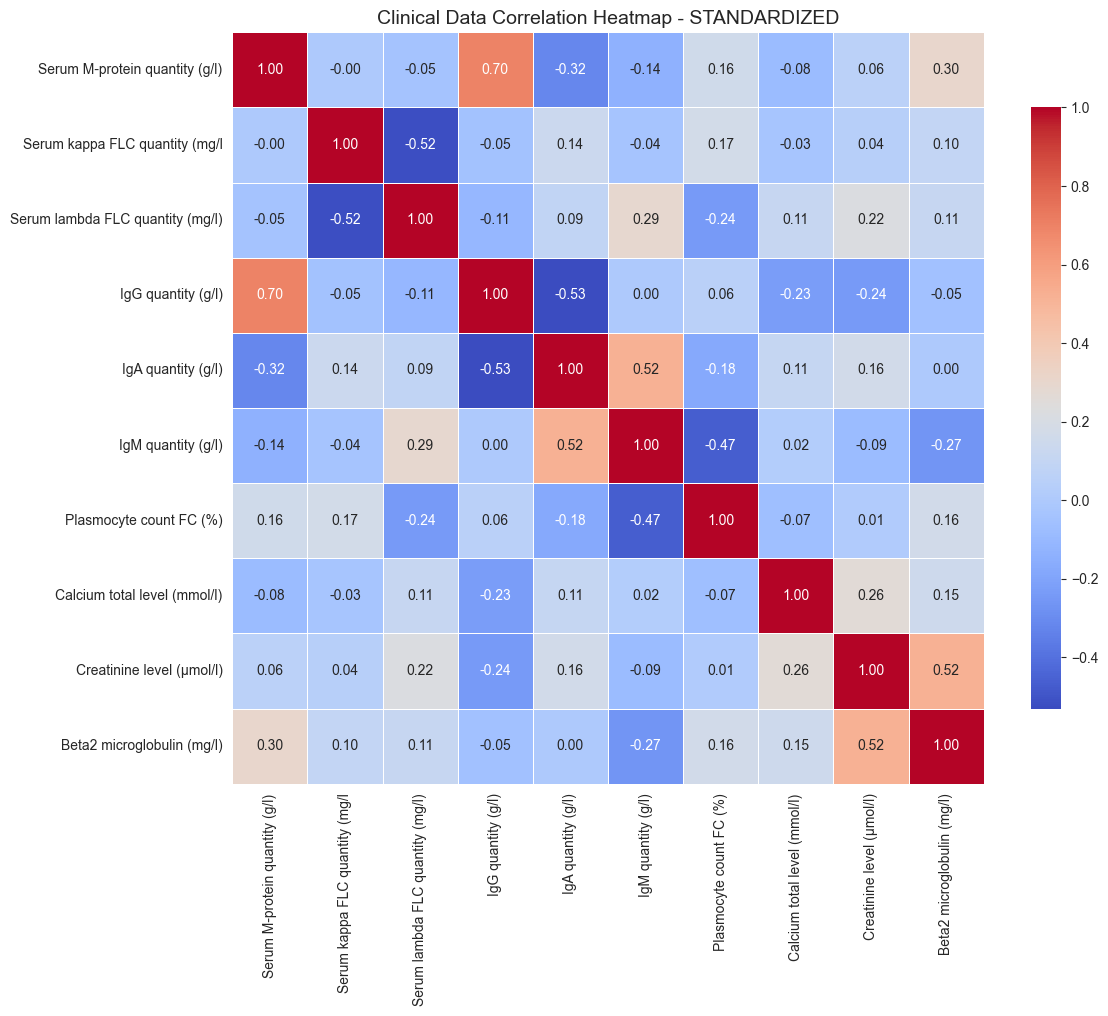

In [12]:
# HEATMAP FROM SCALED
plt.figure(figsize=(12,10))
corr = clinical_scaled.corr(method="spearman")  # pearson/spearman
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Clinical Data Correlation Heatmap - STANDARDIZED", fontsize=14)
plt.tight_layout()
plt.show()

- The diagnosis of myeloma is based on the presence of at least 10% clonal bone marrow plasma cells and monoclonal protein in serum or urine

In [25]:
# PRESENCE OF FC
FC_count = (df["Plasmocyte count FC (%)"] >= 10).sum()
print(f"Count of patient with FC >= 10%: {FC_count}")
print(f"Count of patient with FC < 10%: {(df["Plasmocyte count FC (%)"] < 10).sum()}")
print(f"Number of Nan in FC: {(df["Plasmocyte count FC (%)"].isna()).sum()}")
print()

# MONOCLONAL PROTEIN SERUM
mean_M_serum_above_FC = df.loc[df["Plasmocyte count FC (%)"] >= 10, "Serum M-protein quantity (g/l)"].mean()
mean_M_serum_below_FC = df.loc[df["Plasmocyte count FC (%)"] < 10, "Serum M-protein quantity (g/l)"].mean()
print(f"Mean M serum above FC: {mean_M_serum_above_FC}")
print(f"Mean M serum below FC: {mean_M_serum_below_FC}")

Count of patient with FC >= 10%: 27
Count of patient with FC < 10%: 26
Number of Nan in FC: 19

Mean M serum above FC: 38.14
Mean M serum below FC: 31.82


- high levels of serum β2-microglobulin => High risk disease (Stage III)

Spearman correlation: r = 0.930, p = 9.824e-31



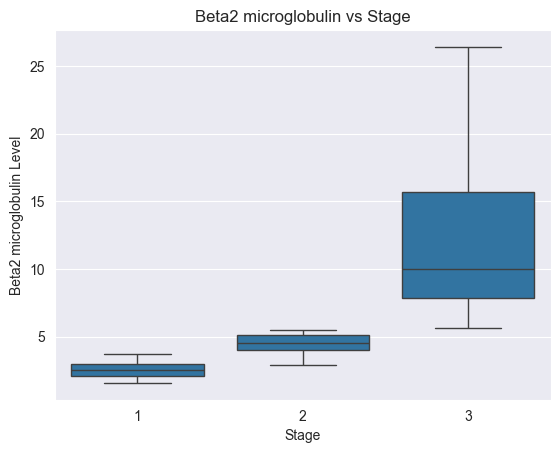

In [44]:
# CORRELATION WITH SPEARMAN
pd.set_option('future.no_silent_downcasting', True)
df['Stage'] = df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

data = df[['Beta2 microglobulin (mg/l)', 'Stage']].dropna()
r, p = spearmanr(data['Beta2 microglobulin (mg/l)'], data['Stage'])
print(f"Spearman correlation: r = {r:.3f}, p = {p:.3e}")   # r +1 => strong correlation
print()                                                    # p < 0.05 => significant


# VISUALIZATION
sns.boxplot(x='Stage', y='Beta2 microglobulin (mg/l)', data=data)
plt.xlabel('Stage')
plt.ylabel('Beta2 microglobulin Level')
plt.title('Beta2 microglobulin vs Stage')
plt.show()

Myeloma-related organ dysfunction (CRAB criteria) -> Hypercalcemia (serum calcium >11.5 mg/dl [2.88 mmol/liter])

In [45]:
calcium_above = (df['Calcium total level (mmol/l)'] > 2.88).sum()
calcium_below = (df['Calcium total level (mmol/l)'] <= 2.88).sum()

print(f"Počet pacientov s Ca > 2.88 mmol/l: {calcium_above}")
print(f"Počet pacientov s Ca ≤ 2.88 mmol/l: {calcium_below}")

Počet pacientov s Ca > 2.88 mmol/l: 7
Počet pacientov s Ca ≤ 2.88 mmol/l: 63


Renal insufficiency (serum creatinine >2 mg/dl [177 μmol/liter])

In [46]:
creatinine_above = (df['Creatinine level (µmol/l)'] > 177).sum()
creatinine_below = (df['Creatinine level (µmol/l)'] <= 177).sum()

print(f"Počet pacientov s Creatinine > 177 µmol/l: {creatinine_above}")
print(f"Počet pacientov s Creatinine ≤ 177 µmol/l: {creatinine_below}")

Počet pacientov s Creatinine > 177 µmol/l: 8
Počet pacientov s Creatinine ≤ 177 µmol/l: 62


KRUSKAL-WALLIS TEST FOR RELATION BETWEEN STAGE OF MM AND CLINICAL BIOMARKER
#
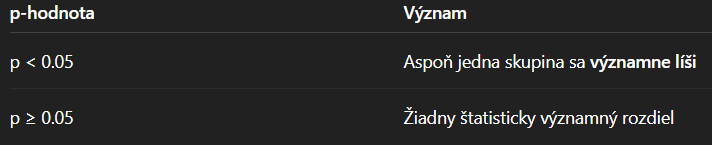

Kruskal-Wallis: Serum M-protein quantity (g/l) -> H = 11.841, p = 0.0027 => Significant: True


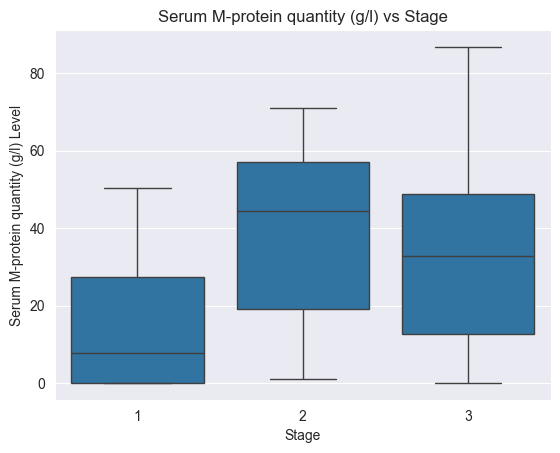

Kruskal-Wallis: Serum kappa FLC quantity (mg/l -> H = 1.066, p = 0.5868 => Significant: False


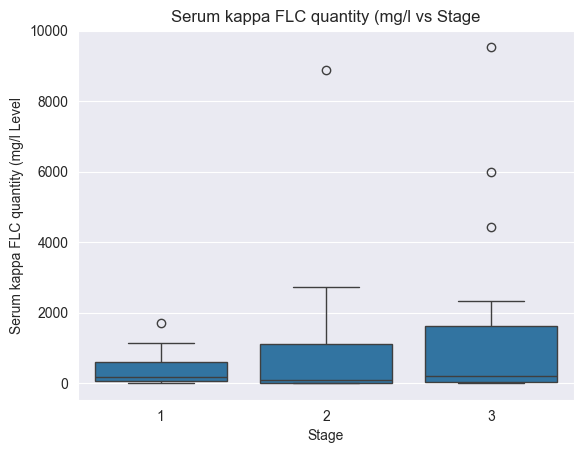

Kruskal-Wallis: Serum lambda FLC quantity (mg/l) -> H = 0.202, p = 0.9039 => Significant: False


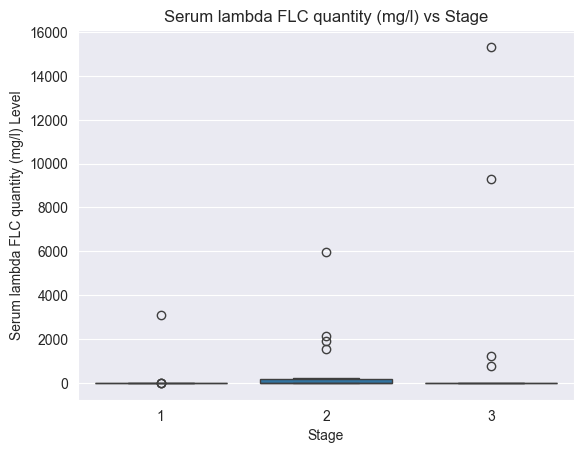

Kruskal-Wallis: IgG quantity (g/l) -> H = 1.230, p = 0.5406 => Significant: False


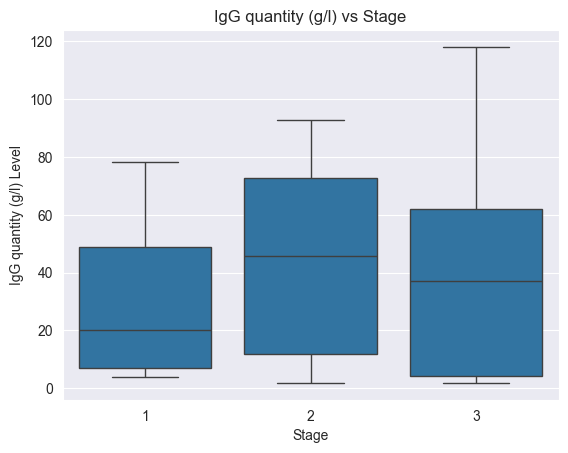

Kruskal-Wallis: IgA quantity (g/l) -> H = 2.509, p = 0.2852 => Significant: False


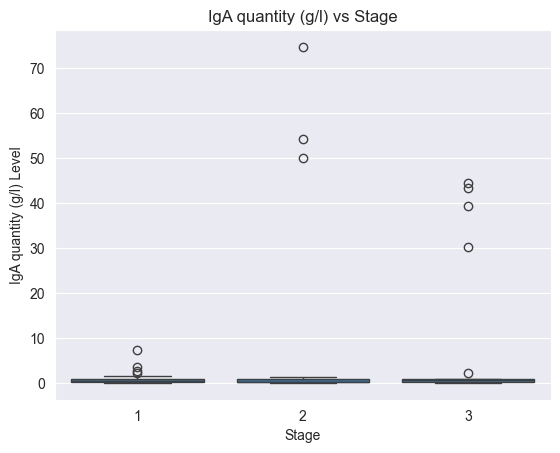

Kruskal-Wallis: IgM quantity (g/l) -> H = 5.580, p = 0.0614 => Significant: False


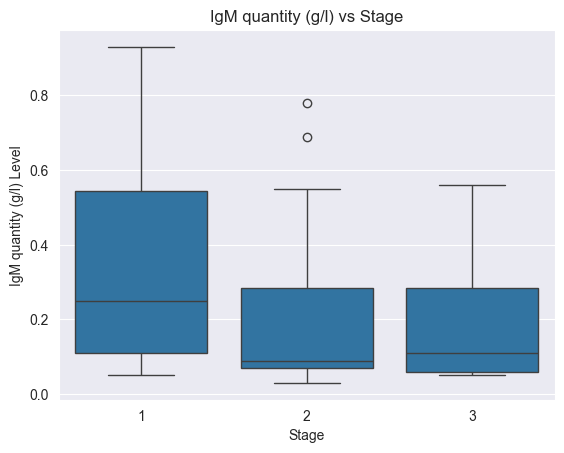

Kruskal-Wallis: Plasmocyte count FC (%) -> H = 2.104, p = 0.3492 => Significant: False


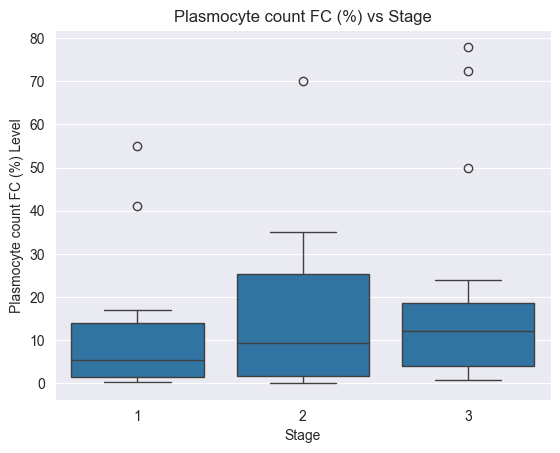

Kruskal-Wallis: Calcium total level (mmol/l) -> H = 2.902, p = 0.2343 => Significant: False


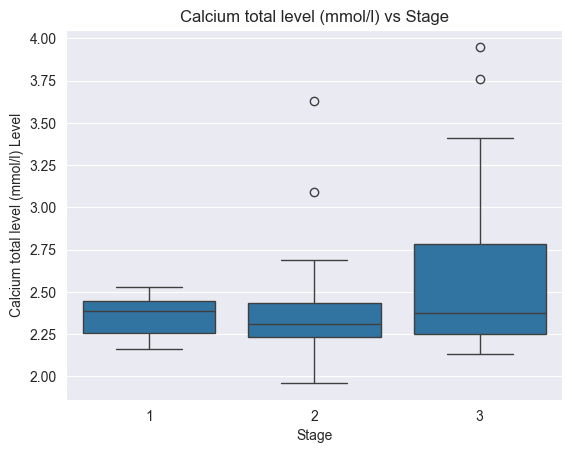

Kruskal-Wallis: Creatinine level (µmol/l) -> H = 16.690, p = 0.0002 => Significant: True


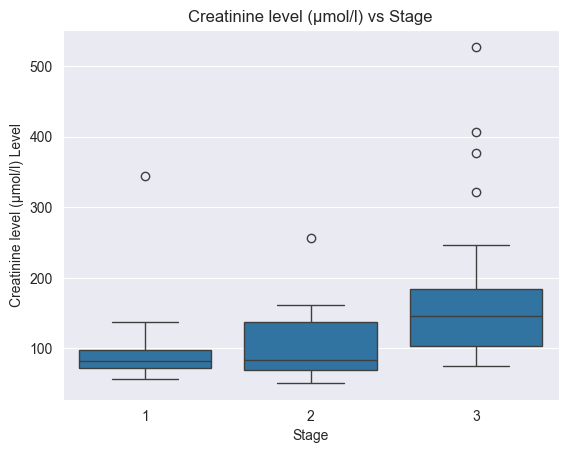

Kruskal-Wallis: Beta2 microglobulin (mg/l) -> H = 58.784, p = 0.0000 => Significant: True


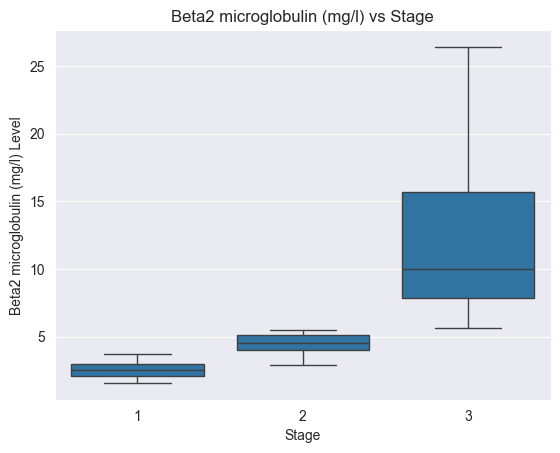

In [23]:
pd.set_option('future.no_silent_downcasting', True)
df['Stage'] = df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

clinical_features = df.select_dtypes(include=['number']).columns

for feature in clinical_features:

    stage1 = df[df['Stage'] == 1][feature].dropna()
    stage2 = df[df['Stage'] == 2][feature].dropna()
    stage3 = df[df['Stage'] == 3][feature].dropna()

    stat, p_value = kruskal(stage1, stage2, stage3)
    print(f"Kruskal-Wallis: {feature} -> H = {stat:.3f}, p = {p_value:.4f} => Significant: {p_value < 0.05}")

    # VISUALIZATION
    data = df[[feature, 'Stage']].dropna()
    sns.boxplot(x='Stage', y=feature, data=data)
    plt.xlabel('Stage')
    plt.ylabel(f'{feature} Level')
    plt.title(f'{feature} vs Stage')
    plt.show()